In [1]:
import pandas as pd
df=pd.read_csv('CarPrice_Assignment.csv')

In [2]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [4]:
X=df[['enginesize']]
y=df['price']

In [5]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
lin_reg=LinearRegression()
lin_reg.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


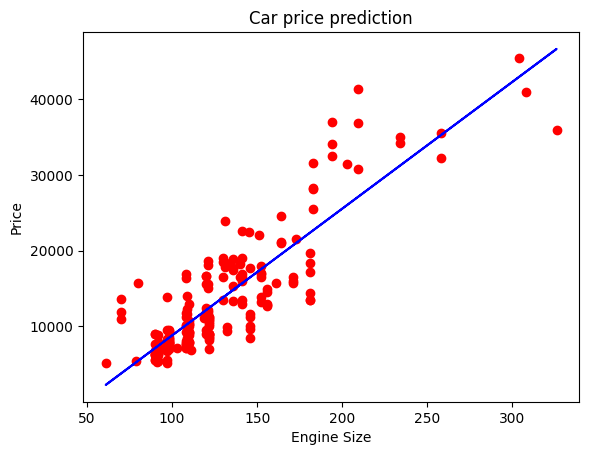

In [6]:
plt.scatter(X,y,color='red')
plt.plot(X,lin_reg.predict(X),color='blue')
plt.title("Car price prediction")
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

In [22]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
poly_reg=PolynomialFeatures(degree=4)
X_poly=poly_reg.fit_transform(X)
lin_reg2=LinearRegression()
lin_reg2.fit(X_poly,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


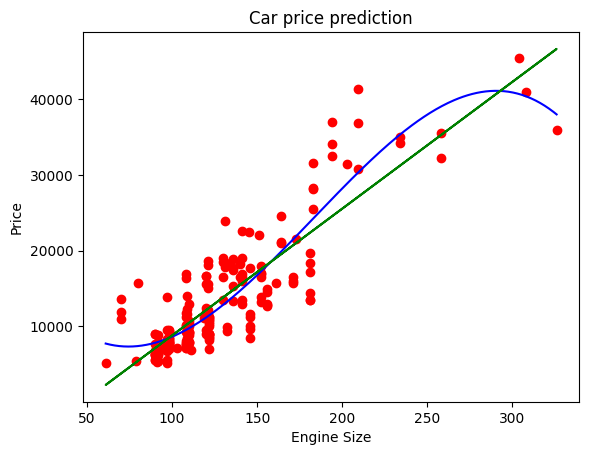

In [32]:
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_range_poly = poly_reg.transform(X_range)
plt.scatter(X, y, color='red', label='Actual data')
plt.plot(X_range,lin_reg2.predict(X_range_poly),color='blue')
plt.plot(X,lin_reg.predict(X),color='green')
plt.title("Car price prediction")
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

In [29]:
y_pred_poly=lin_reg2.predict(poly_reg.transform([[200]]))
print("Polynomial Regression prediction for level 200:", y_pred_poly)

Polynomial Regression prediction for level 200: [28205.13190985]


c:\Users\RISHITHA SRIJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [30]:
from sklearn.metrics import *
import numpy as np

y_pred=lin_reg.predict(X)

mse=mean_squared_error(y,y_pred)
mae=mean_absolute_error(y,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y,y_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Squared Error (MSE): 14980261.40555132
Mean Absolute Error (MAE): 2815.0223538364103
Root Mean Squared Error (RMSE): 3870.4342657576967
R² Score: 0.7641291357806176


In [31]:
y_poly_pred = lin_reg2.predict(poly_reg.transform(X))

mse_p = mean_squared_error(y, y_poly_pred)
mae_p = mean_absolute_error(y, y_poly_pred)
rmse_p = np.sqrt(mse_p)
r2_p = r2_score(y, y_poly_pred)

print("Polynomial MSE:", mse_p)
print("Polynomial MAE:", mae_p)
print("Polynomial RMSE:", rmse_p)
print("Polynomial R²:", r2_p)


Polynomial MSE: 13091408.850448111
Polynomial MAE: 2692.9295996059623
Polynomial RMSE: 3618.2051973938833
Polynomial R²: 0.7938699575522645
